TASK 2-FUTUREINTERNS

In [47]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
telco_customer_churn = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", telco_customer_churn.head())

/tmp/ipykernel_32864/602980236.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  telco_customer_churn = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

In [48]:
print(telco_customer_churn['Churn'].unique())
print(telco_customer_churn['Churn'].value_counts())

['No' 'Yes']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [49]:
#now we begin the cleaning of data

#just in case, lets remove thr ows hat are null
telco_customer_churn = telco_customer_churn.dropna()

telco_customer_churn.isnull().sum() #this shows us if there no null

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [50]:
#as seen above, we have no null values
#let us check the type of data each column is
print(telco_customer_churn.dtypes)
#keep in mind we need number to work with, to plot, to see where we things lie

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [51]:
#we need numbers not objects, we need integer
#also, encoding is important with dataset as we have  alot catergories
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

#we can begin converting into numbers first
telco_customer_churn['TotalCharges'] = pd.to_numeric(telco_customer_churn['TotalCharges'], errors='coerce') #converts total charges to numbers instead of objects
#remove the missing of "totalcharges
telco_customer_churn.dropna(subset=['TotalCharges'], inplace=True)

In [52]:
#churn is our "target" in a way, it has to be form of binary data(o and 1)
telco_customer_churn['Churn']= telco_customer_churn['Churn'].map({'Yes':1,'No':0})
#to verify what was performd
telco_customer_churn['Churn'].value_counts()



,count
Churn,
0,5163
1,1869


In [53]:
#lets create a list of the catergorical variables present so we can conduct encoding on the catergoical columns
qualitative = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

#the remaining numeric columns
quantitative = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
#

**DASHBOARD ADDITION**

*`KPI CARD`*

In [54]:
#the below shows the churn distribution
print(telco_customer_churn['Churn'].value_counts())

#the % of the churn
print(telco_customer_churn['Churn'].value_counts(normalize=True)* 100)
#

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [55]:
# 1. Check the shape – it should be (7032, 21) after dropping missing TotalCharges
print("Shape:", telco_customer_churn.shape)

# View first two rows to see actual Churn values
print(telco_customer_churn[['Churn']].head(2))

# Identify unique values present in Churn
print("Unique values:", telco_customer_churn['Churn'].unique())

# 4. Check for any missing values in Churn
print("Missing count:", telco_customer_churn['Churn'].isna().sum())

Shape: (7032, 21)
   Churn
0      0
1      0
Unique values: [0 1]
Missing count: 0


**CHURN BY VARIABLES-WHY **

 *CHURN BY Tenure*

Text(0.5, 1.0, 'Churn Distribution by Tenure')

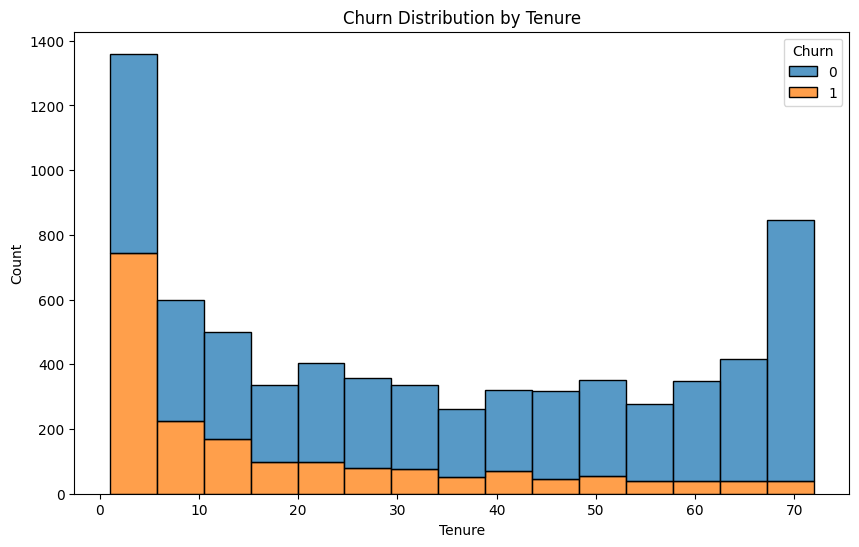

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

#we will plot churn by tenure
plt.figure(figsize=(10, 6))
sns.histplot(data=telco_customer_churn, x='tenure', hue='Churn', multiple='stack')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Churn Distribution by Tenure')

In [58]:
#to analyse the above:
#median
median_tenure_churn = telco_customer_churn[telco_customer_churn['Churn'] == 1]['tenure'].median() #this prints our Q2
print("Median tenure for churned customers:", median_tenure_churn)

Median tenure for churned customers: 10.0


The above shows us that within the first 12 months, 47% of churns happen. So, it most likely churn in earlier time.  While after 20 months, it decreases drastically.

This demonstates that a customer is most likely to stay when they survive the first 12 months.
Thus, retention effort must be front-loaded.


***Churn by Internet***

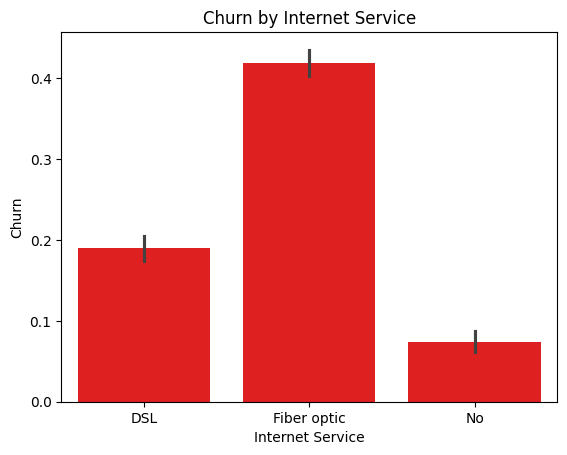

In [59]:
#a bargraph based of the churn and internet services
sns.barplot(data=telco_customer_churn, x='InternetService', y='Churn', color='red')
plt.xlabel('Internet Service')
plt.ylabel('Churn')
plt.title('Churn by Internet Service')
plt.show()

Based on the above graph, it seen that Fiber optic is the highest service that customer are leaving.

*CHURN BY TYPE OF CONTRACT*

Text(0.5, 1.0, 'Churn by Contract Type')

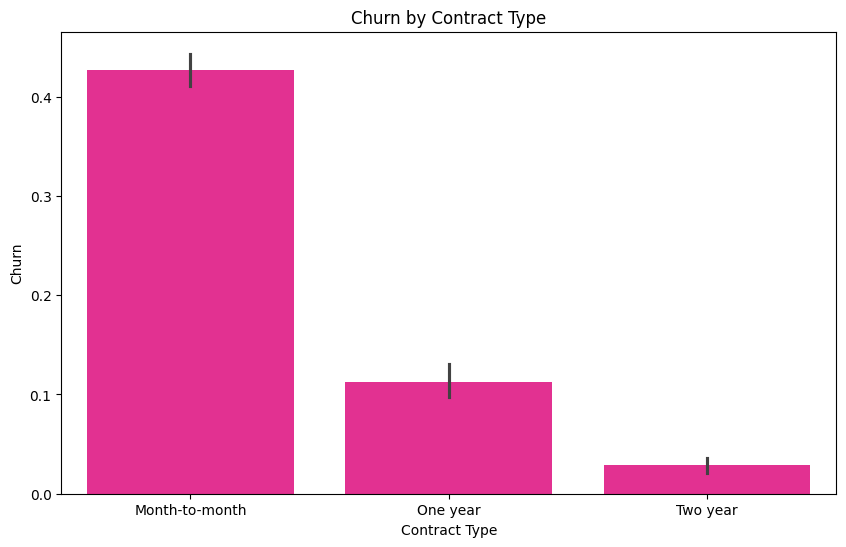

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(data=telco_customer_churn, x='Contract', y='Churn', color='deeppink')
plt.xlabel('Contract Type')
plt.ylabel('Churn')
plt.title('Churn by Contract Type')

The contract that is most risk based on the height of the bars is "Month-to-month".This means that they also most likely to churn.  This decreases by over 70% as it moves to an annual plan. It is simpler to lose those with commitment that is NOT HIGH.

*Churn by monthly charges*

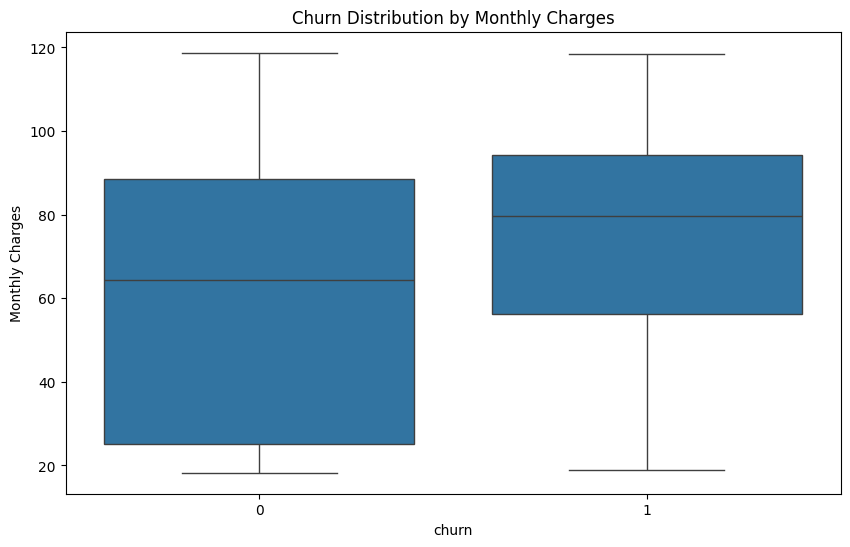

In [61]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=telco_customer_churn, x='Churn', y='MonthlyCharges')
plt.xlabel('churn')
plt.ylabel('Monthly Charges')
plt.title('Churn Distribution by Monthly Charges')
plt.show()

Those who have lower pricing are those most likely to stay.
Sensitive pricing impacts customer retention as churn is most likely with customers with a increased monthly subscription charges.


**Customer analysis**

*RETENTION TREND*

In [62]:
average_tenure= telco_customer_churn['tenure'].mean()
print(f'{average_tenure} months is the average lifetime of customers')
#

32.421786120591584 months is the average lifetime of customers
